In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Grafikler için stil ayarları
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

print("EDA Analizi için veri seti yükleniyor")
df = pd.read_csv("C:/labs/data/islenmis/ready_to_train_120k.csv")

#Veri setine genel bir bakış
print("\n===VERİ SETİNİN İLK 5 SATIRI ===")
print(df.head())

print("\n===VERİ SETİ GENEL BİLGİLERİ ===")
print(df.info())

print("\n===SAYISAL ÖZELLİKLERİN ÖZET İSTATİSTİKLERİ ===")
print(df.describe())

EDA Analizi için veri seti yükleniyor

===VERİ SETİNİN İLK 5 SATIRI ===
   ip.proto  tcp.srcport  tcp.dstport  udp.srcport  ...  tcp.flags  tcp.window_size_value  label  packet_size_category
0         1            0            0            0  ...          0                      0      1                     0
1         1            0            0            0  ...          0                      0      1                     1
2         6        36072           22            0  ...         24                    246      0                     2
3         6          443        43444            0  ...         20                      0      0                     0
4         6        33170           80            0  ...          2                  64240      0                     1

[5 rows x 9 columns]

===VERİ SETİ GENEL BİLGİLERİ ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dty

In [7]:
plt.figure(figsize=(10 , 5))
#Paket boyutunun dağılımı
sns.kdeplot(data=df , x= 'frame.len' , hue='label' , fill=True, common_norm=False, palette='Set1' , alpha=0.5)
plt.title('Normal ve Saldırı Trafiğinde Paket Boyutu Dağılımı')
plt.xlabel('Paket Boyutu')
plt.ylabel('Yoğunluk (Density)')
plt.legend(title='Sınıf', labels=['Saldırı(1)' , 'Normal(0)'])
plt.show()

ValueError: Could not interpret value `frame.len` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x500 with 0 Axes>

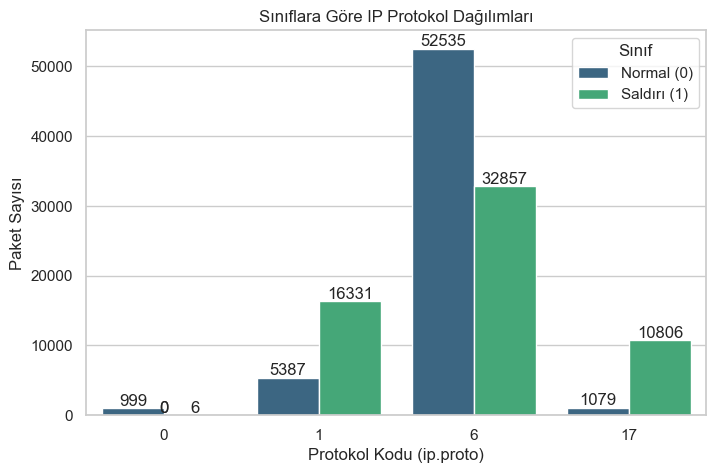

In [8]:
plt.figure(figsize=(8,5))
ax = sns.countplot(data=df , x = 'ip.proto' , hue='label' , palette='viridis')
plt.title('Sınıflara Göre IP Protokol Dağılımları')
plt.xlabel('Protokol Kodu (ip.proto)')
plt.ylabel('Paket Sayısı')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}' , (p.get_x() + p.get_width() / 2., p.get_height()),
               ha='center', va='center', xytext = (0,5), textcoords='offset points')

plt.legend(title='Sınıf', labels=['Normal (0)', 'Saldırı (1)'])
plt.show()

In [9]:
plt.figure(figsize=(12 , 5))
#Veriyi 1 saniye zaman dilimlerine bölerek paket sayılarına bak
df['time_round'] = df['frame.time_relative'].round()
velocity_df = df.groupby(['time_round' , 'label']).size().reset_index(name='packet_count')

sns.lineplot(data=velocity_df, x='time_round' , y='packet_count', hue='label', palette='coolwarm', linewidth=2)
plt.title('Zamana göre trafik yoğunluğu')
plt.xlabel('Simülasyon Zamanı')
plt.ylabel('Saniyedeki Paket Sayısı')
plt.legend(title='Sınıf' , labels=['Normal(0)' , 'Saldırı (1)'])
plt.show()

KeyError: 'frame.time_relative'

<Figure size 1200x500 with 0 Axes>

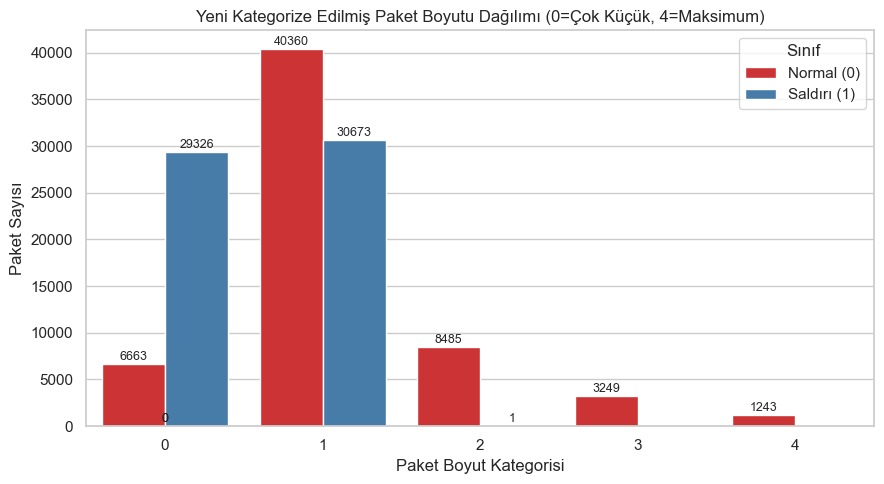

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Eğitime hazır pırlanta veri setini yüklüyoruz
df_new = pd.read_csv("C:/labs/data/islenmis/ready_to_train_120k.csv")

plt.figure(figsize=(9, 5))
# Kategorik hale getirdiğimiz paket boyutlarının sınıflara göre oranını inceliyoruz
ax = sns.countplot(data=df_new, x='packet_size_category', hue='label', palette='Set1')
plt.title('Yeni Kategorize Edilmiş Paket Boyutu Dağılımı (0=Çok Küçük, 4=Maksimum)')
plt.xlabel('Paket Boyut Kategorisi')
plt.ylabel('Paket Sayısı')

# Barların üzerine sayıları basalım
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=9)

plt.legend(title='Sınıf', labels=['Normal (0)', 'Saldırı (1)'])
plt.tight_layout()
plt.show()

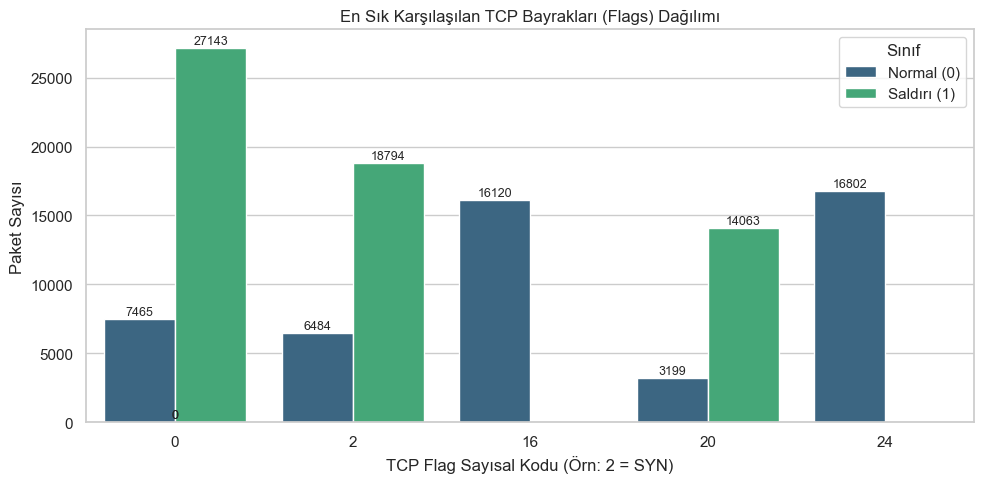

In [15]:
plt.figure(figsize=(10, 5))

# En çok kullanılan ilk 5 TCP flag kodunu alalım (0 genelde UDP paketlerini veya bayraksızları temsil eder)
top_flags = df_new['tcp.flags'].value_counts().head(5).index
df_top_flags = df_new[df_new['tcp.flags'].isin(top_flags)]

ax = sns.countplot(data=df_top_flags, x='tcp.flags', hue='label', palette='viridis')
plt.title('En Sık Karşılaşılan TCP Bayrakları (Flags) Dağılımı')
plt.xlabel('TCP Flag Sayısal Kodu (Örn: 2 = SYN)')
plt.ylabel('Paket Sayısı')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=9)

plt.legend(title='Sınıf', labels=['Normal (0)', 'Saldırı (1)'])
plt.tight_layout()
plt.show()

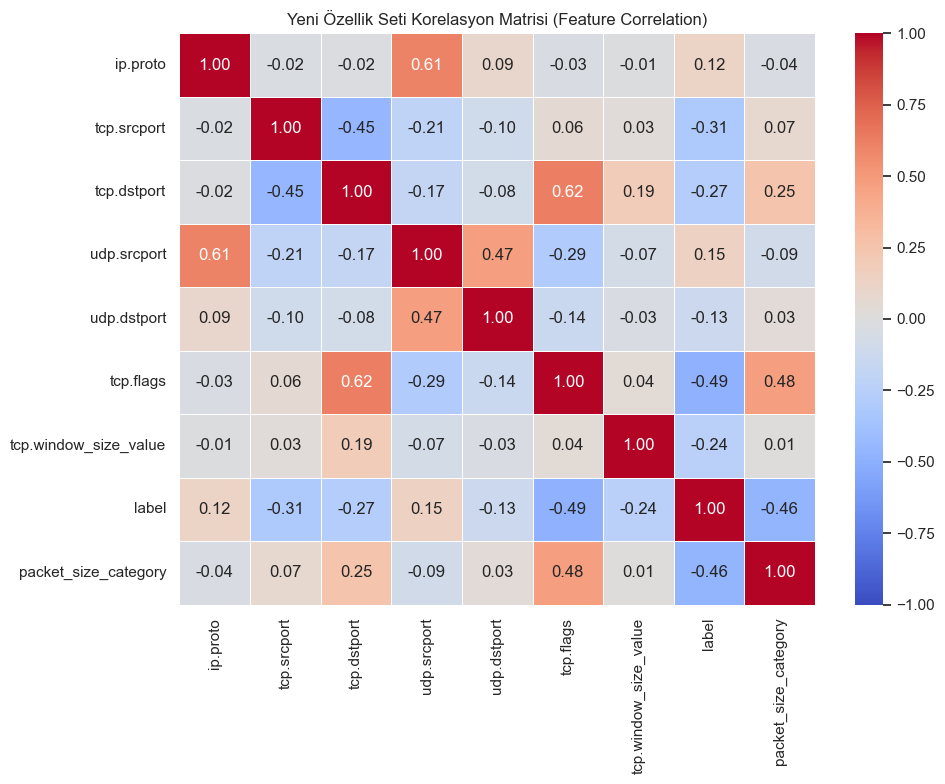

In [14]:
plt.figure(figsize=(10, 8))

# Tüm kolonların birbiriyle olan doğrusal ilişkisini hesaplıyoruz
correlation_matrix = df_new.corr()

# Isı haritasını çizelim
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Yeni Özellik Seti Korelasyon Matrisi (Feature Correlation)')
plt.tight_layout()
plt.show()